In [24]:
#kütüphaneler
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    roc_auc_score, confusion_matrix, classification_report,
    roc_curve, precision_recall_curve
)
from imblearn.over_sampling import RandomOverSampler

# renkler
COLORS = {
    'Logistic Reg.': '#2196F3',
    'KNN':           '#4CAF50',
    'Decision Tree': '#FF9800',
    'Random Forest': '#E91E63',
    'SVM':           '#9C27B0',
    'Naive Bayes':   '#00BCD4',
    'Neural Net':    '#F44336',
}
plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False,
                     'axes.spines.right': False})

In [25]:
#veri okuma ve temel bilgiler
df = pd.read_csv('online_shoppers_intention.csv')

print("VERİ SETİ HAKKINDA")
print(f"Satır × Sütun : {df.shape}")
print(f"Eksik değer   : {df.isnull().sum().sum()}")
print(f"\nSütun tipleri:\n{df.dtypes}")
print(f"\nHedef sınıf dağılımı:\n{df['Revenue'].value_counts()}")
print(f"\nSayısal özet:\n{df.describe().round(2)}")

VERİ SETİ HAKKINDA
Satır × Sütun : (12330, 18)
Eksik değer   : 0

Sütun tipleri:
Administrative               int64
Administrative_Duration    float64
Informational                int64
Informational_Duration     float64
ProductRelated               int64
ProductRelated_Duration    float64
BounceRates                float64
ExitRates                  float64
PageValues                 float64
SpecialDay                 float64
Month                       object
OperatingSystems             int64
Browser                      int64
Region                       int64
TrafficType                  int64
VisitorType                 object
Weekend                       bool
Revenue                       bool
dtype: object

Hedef sınıf dağılımı:
Revenue
False    10422
True      1908
Name: count, dtype: int64

Sayısal özet:
       Administrative  Administrative_Duration  Informational  \
count        12330.00                 12330.00       12330.00   
mean             2.32                    80

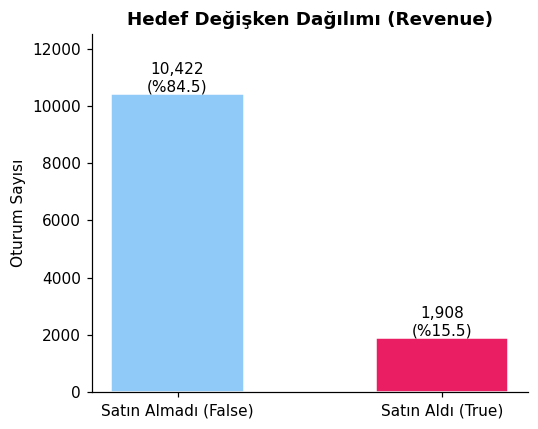

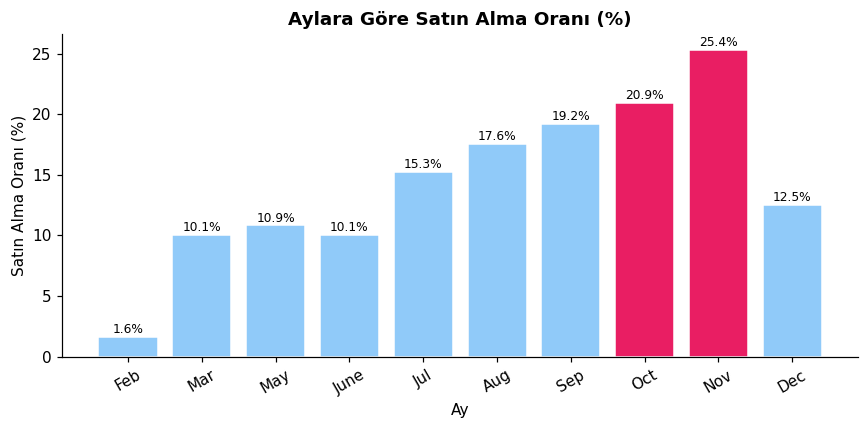

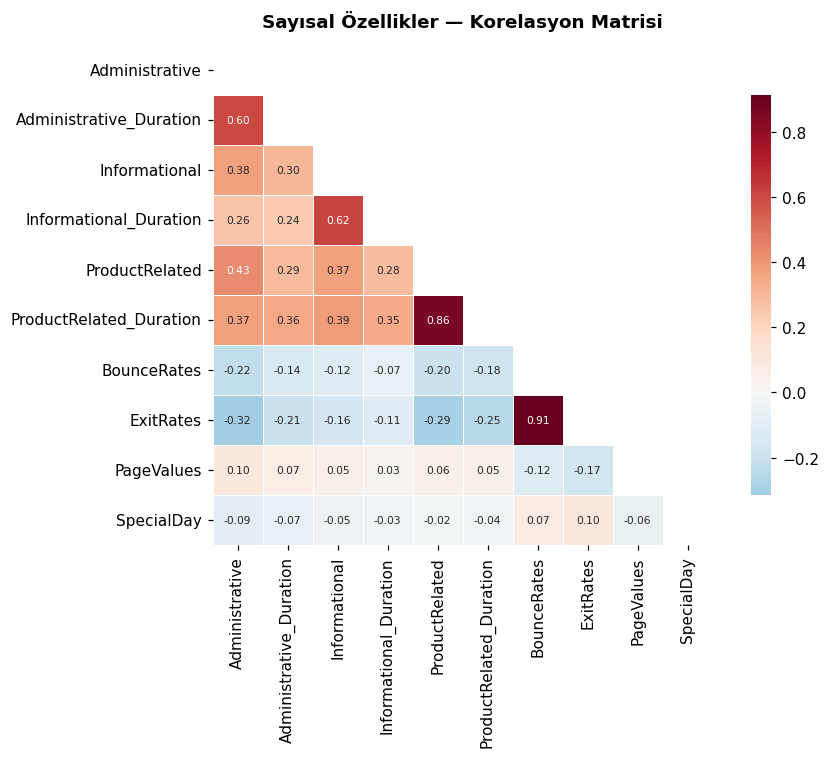

In [26]:
#veri analizi

# hedef sınıf dağılımı
counts = df['Revenue'].value_counts()
fig, ax = plt.subplots(figsize=(5, 4))
bars = ax.bar(['Satın Almadı (False)', 'Satın Aldı (True)'],
              counts.values, color=['#90CAF9', '#E91E63'],
              edgecolor='white', width=0.5)
for b, v in zip(bars, counts.values):
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 80,
            f'{v:,}\n(%{v/len(df)*100:.1f})', ha='center', fontsize=10)
ax.set_title('Hedef Değişken Dağılımı (Revenue)', fontsize=12, fontweight='bold')
ax.set_ylabel('Oturum Sayısı')
ax.set_ylim(0, max(counts.values) * 1.2)
plt.tight_layout()
plt.show()

# Aya göre satın alma oranı
month_order = ['Feb','Mar','May','June','Jul','Aug','Sep','Oct','Nov','Dec']
month_data  = df.groupby('Month')['Revenue'].mean().reindex(month_order) * 100

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(month_data.index, month_data.values,
              color=['#E91E63' if v > 20 else '#90CAF9' for v in month_data.values],
              edgecolor='white')
ax.set_title('Aylara Göre Satın Alma Oranı (%)', fontsize=12, fontweight='bold')
ax.set_xlabel('Ay'); ax.set_ylabel('Satın Alma Oranı (%)')
ax.tick_params(axis='x', rotation=30)
for b, v in zip(bars, month_data.values):
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.3,
            f'{v:.1f}%', ha='center', fontsize=8)
plt.tight_layout()
plt.show()


#sayısal özellikler korelasyon matrisi ────────────────
num_cols = ['Administrative','Administrative_Duration','Informational',
            'Informational_Duration','ProductRelated','ProductRelated_Duration',
            'BounceRates','ExitRates','PageValues','SpecialDay']
corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, square=True, linewidths=0.4, ax=ax,
            annot_kws={'size': 7}, cbar_kws={'shrink': 0.8})
ax.set_title('Sayısal Özellikler — Korelasyon Matrisi',
             fontsize=12, fontweight='bold', pad=12)
plt.tight_layout()
plt.show()


Ön İşleme Özeti
One-Hot sonrası özellik sayısı : 28
Eğitim (dengeli)  : 7295 × 0 | 7295 × 1
Test   (dengeli)  : 572 × 0 | 572 × 1


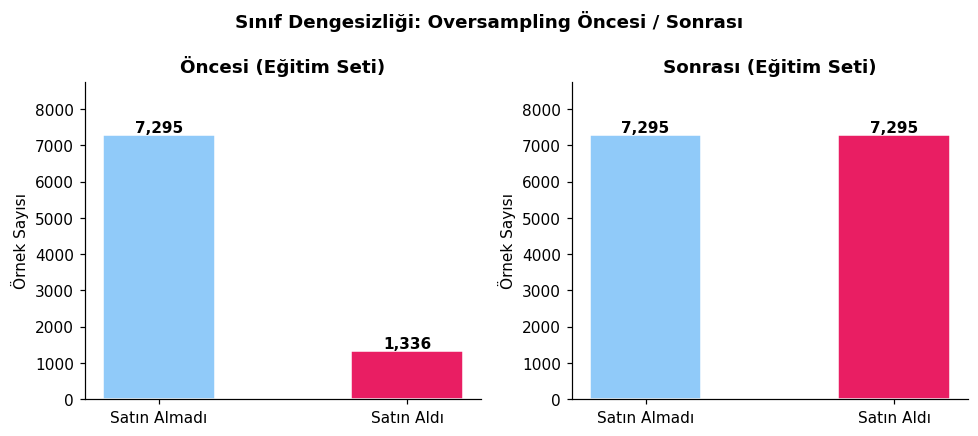

In [27]:
#Ön işleme
# One-Hot Encoding (1-of-C) 
df_enc = pd.get_dummies(df, columns=['Month', 'VisitorType'])
df_enc['Weekend'] = df_enc['Weekend'].astype(int)
df_enc['Revenue'] = df_enc['Revenue'].astype(int)

X = df_enc.drop('Revenue', axis=1).astype(float)
y = df_enc['Revenue']

# %70 / %30 Train-Test split 
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y)

# RandomOverSampler — sadece eğitim setine 
ros = RandomOverSampler(random_state=42)
X_tr_bal, y_tr_bal = ros.fit_resample(X_train, y_train)

# StandardScaler
sc = StandardScaler()
X_tr_sc = sc.fit_transform(X_tr_bal)
X_te_sc  = sc.transform(X_test)

# Dengeli test seti 
pos_idx = np.where(y_test.values == 1)[0]
neg_idx = np.where(y_test.values == 0)[0]
np.random.seed(42)
neg_s   = np.random.choice(neg_idx, len(pos_idx), replace=False)
bal_idx = np.concatenate([pos_idx, neg_s])
X_te_bal = X_te_sc[bal_idx]
y_te_bal = y_test.values[bal_idx]

print("\nÖn İşleme Özeti")
print(f"One-Hot sonrası özellik sayısı : {X.shape[1]}")
print(f"Eğitim (dengeli)  : {(y_tr_bal==0).sum()} × 0 | {(y_tr_bal==1).sum()} × 1")
print(f"Test   (dengeli)  : {(y_te_bal==0).sum()} × 0 | {(y_te_bal==1).sum()} × 1")

#  Oversampling görselleştirme 
fig, axes = plt.subplots(1, 2, figsize=(9, 4))
fig.suptitle('Sınıf Dengesizliği: Oversampling Öncesi / Sonrası',
             fontsize=12, fontweight='bold')
for ax, data, title in zip(
        axes,
        [[(y_train==0).sum(), (y_train==1).sum()],
         [(y_tr_bal==0).sum(), (y_tr_bal==1).sum()]],
        ['Öncesi (Eğitim Seti)', 'Sonrası (Eğitim Seti)']):
    bars = ax.bar(['Satın Almadı', 'Satın Aldı'], data,
                  color=['#90CAF9', '#E91E63'], edgecolor='white', width=0.45)
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel('Örnek Sayısı')
    for b, v in zip(bars, data):
        ax.text(b.get_x()+b.get_width()/2, b.get_height()+60,
                f'{v:,}', ha='center', fontweight='bold')
    ax.set_ylim(0, max(data) * 1.2)
plt.tight_layout()
plt.show()


In [28]:
#MODEL EĞİTİMİ
models_dict = {
    'Logistic Reg.': LogisticRegression(C=1.0, max_iter=1000, random_state=42),
    'KNN':           KNeighborsClassifier(n_neighbors=5, weights='distance'),
    'Decision Tree': DecisionTreeClassifier(max_depth=8, min_samples_leaf=5,
                                             random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42,
                                             n_jobs=-1),
    'SVM':           SVC(kernel='rbf', C=1.0, gamma='scale',
                         probability=True, random_state=42),
    'Naive Bayes':   GaussianNB(),
    
    'Neural Net':    MLPClassifier(hidden_layer_sizes=(10,), activation='logistic',
                                   solver='sgd', learning_rate='adaptive',
                                   max_iter=500, random_state=42),
    
}
results = {}
print("\n Model Eğitimi")
for name, model in models_dict.items():
    model.fit(X_tr_sc, y_tr_bal)
    y_pred = model.predict(X_te_bal)
    y_prob = model.predict_proba(X_te_bal)[:, 1]
    pc, rc, _ = precision_recall_curve(y_te_bal, y_prob)
    results[name] = {
        'Accuracy':  accuracy_score(y_te_bal, y_pred),
        'F1':        f1_score(y_te_bal, y_pred),
        'Precision': precision_score(y_te_bal, y_pred),
        'Recall':    recall_score(y_te_bal, y_pred),
        'TPR':       recall_score(y_te_bal, y_pred),
        'TNR':       recall_score(y_te_bal, y_pred, pos_label=0),
        'AUC-ROC':   roc_auc_score(y_te_bal, y_prob),
        'y_pred': y_pred, 'y_prob': y_prob, 'pc': pc, 'rc': rc,
    }
    print(f"  {name:<16}  Acc:{results[name]['Accuracy']:.3f}  "
          f"F1:{results[name]['F1']:.3f}  "
          f"TPR:{results[name]['TPR']:.3f}  "
          f"TNR:{results[name]['TNR']:.3f}  "
          f"AUC:{results[name]['AUC-ROC']:.3f}")

MN = list(results.keys())


 Model Eğitimi
  Logistic Reg.     Acc:0.803  F1:0.791  TPR:0.745  TNR:0.862  AUC:0.897
  KNN               Acc:0.699  F1:0.666  TPR:0.600  TNR:0.799  AUC:0.753
  Decision Tree     Acc:0.825  F1:0.821  TPR:0.804  TNR:0.846  AUC:0.873
  Random Forest     Acc:0.785  F1:0.746  TPR:0.631  TNR:0.939  AUC:0.914
  SVM               Acc:0.799  F1:0.783  TPR:0.727  TNR:0.871  AUC:0.880
  Naive Bayes       Acc:0.691  F1:0.740  TPR:0.878  TNR:0.505  AUC:0.800
  Neural Net        Acc:0.815  F1:0.805  TPR:0.764  TNR:0.865  AUC:0.897


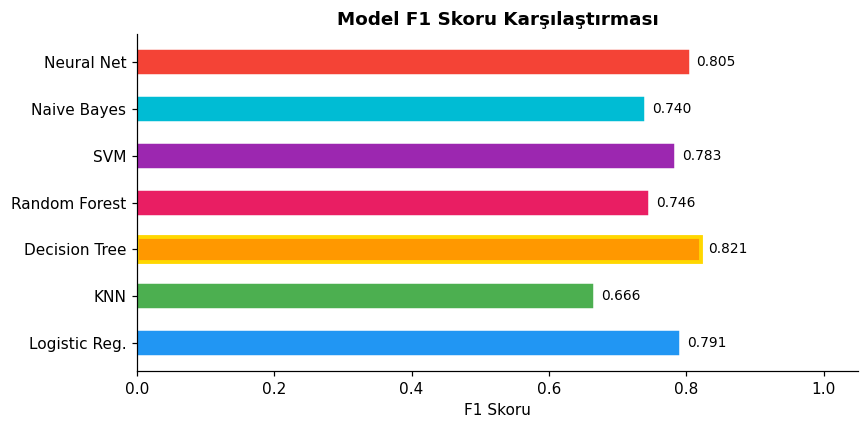

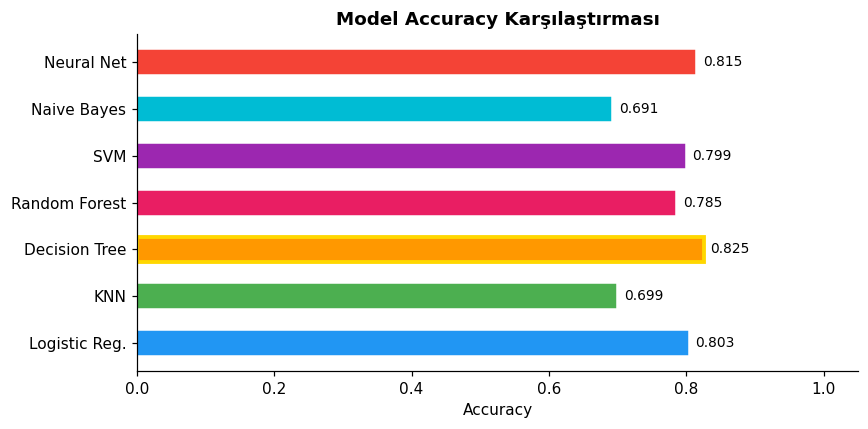

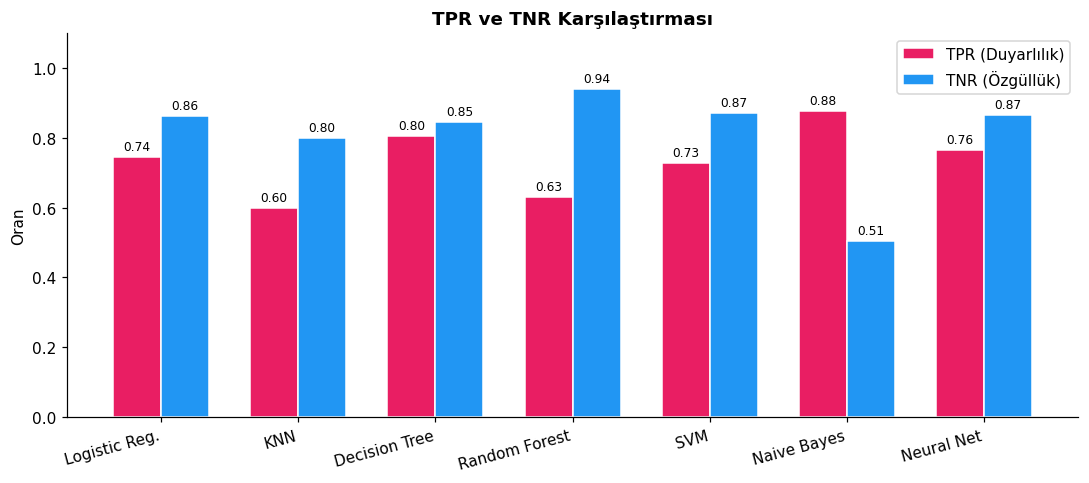

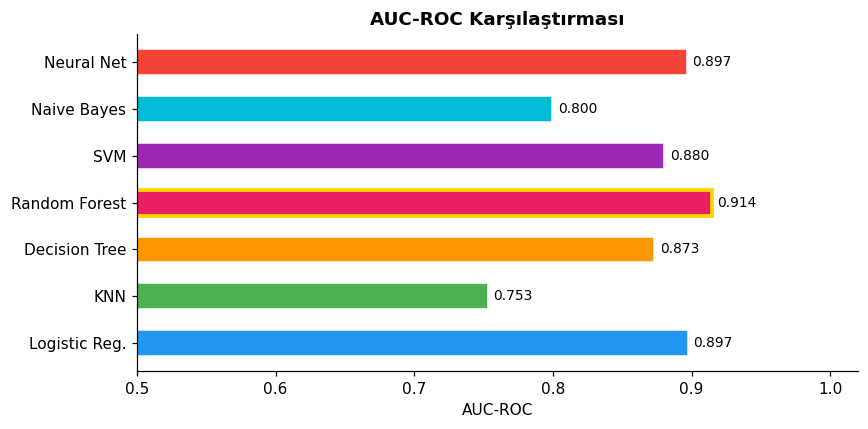

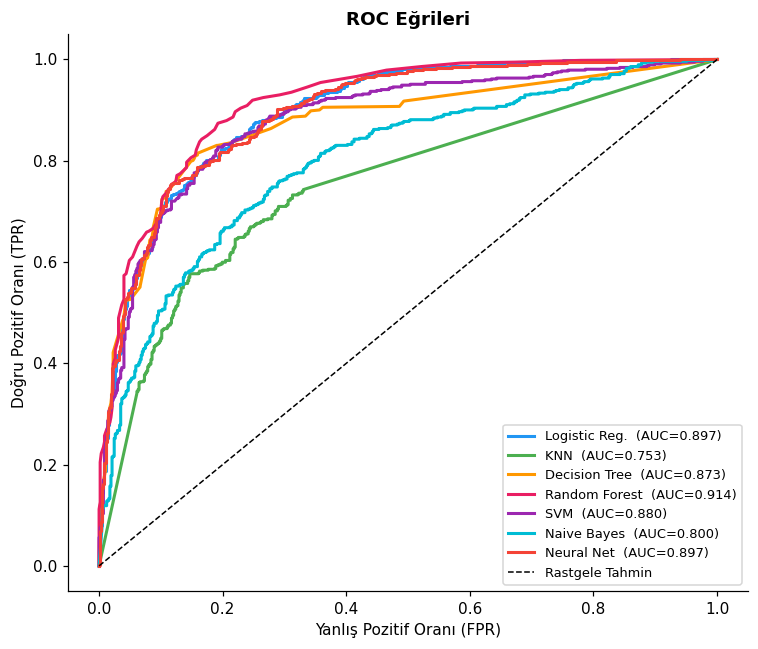

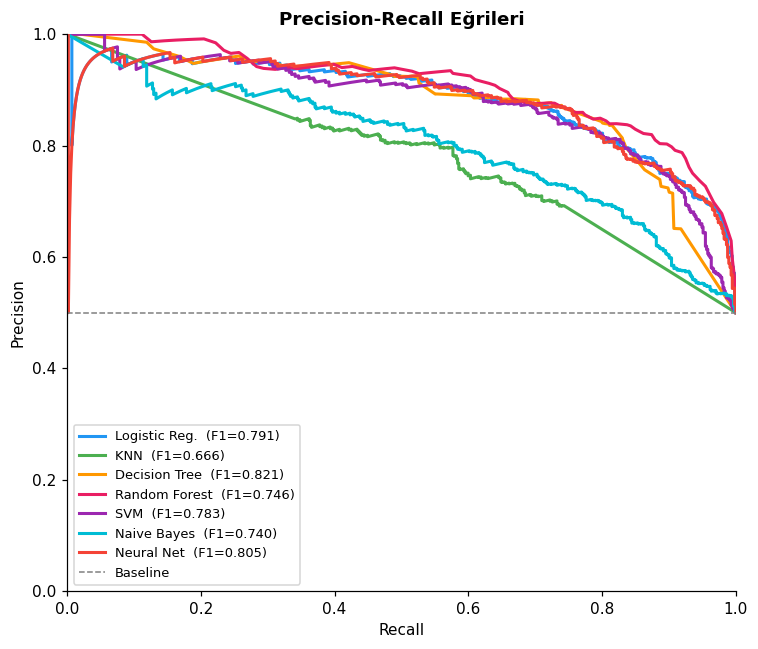

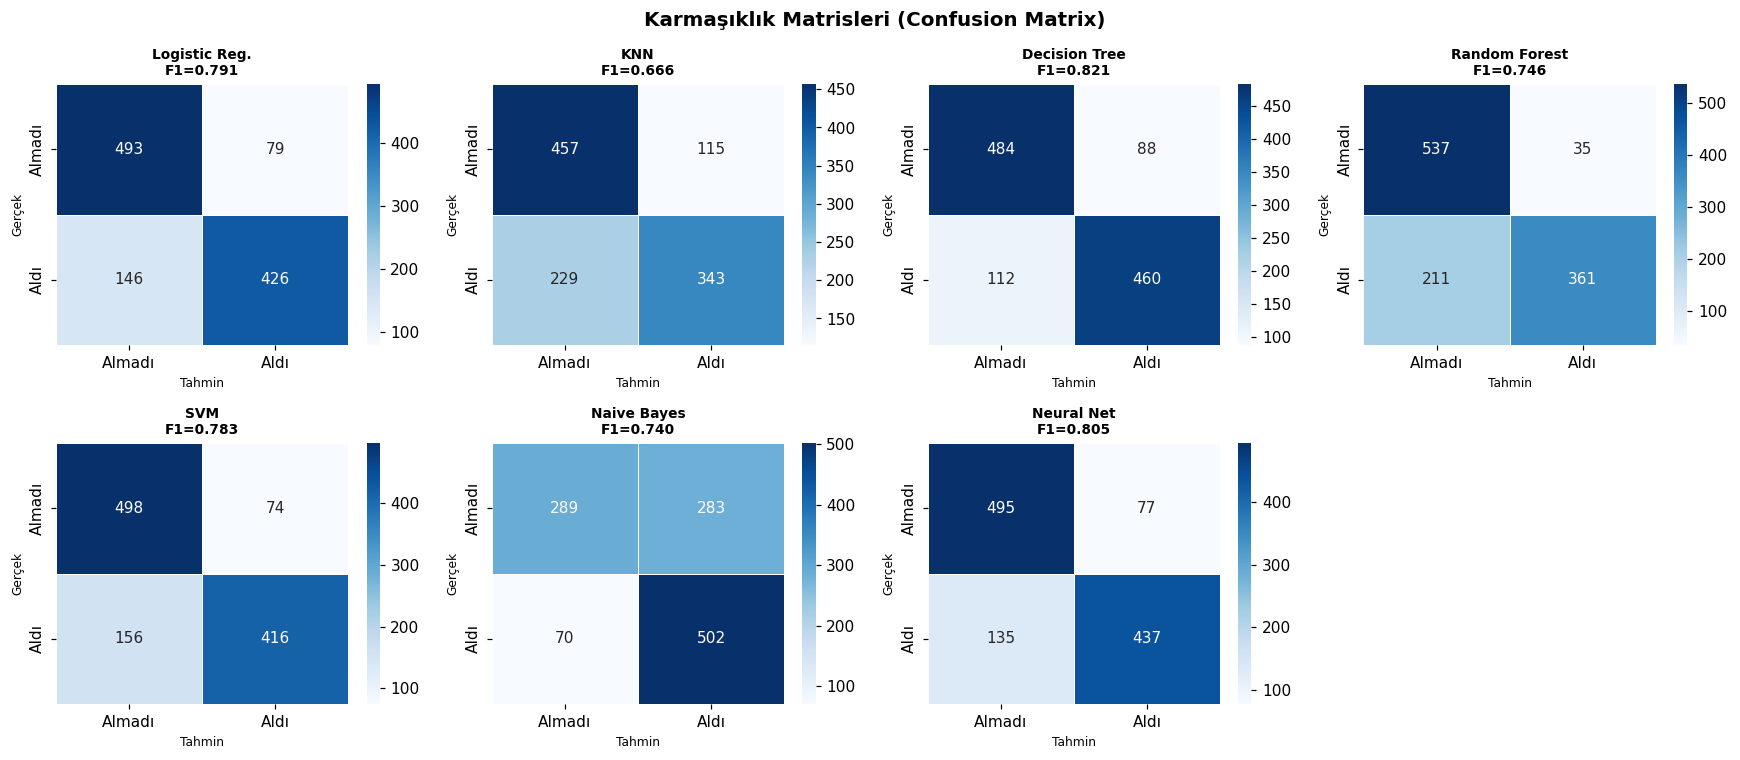

In [29]:
#model karşılaştırma görselleri

# F1 Skor karşılaştırması (sade)
f1_vals = [results[n]['F1'] for n in MN]
fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(MN, f1_vals,
               color=[COLORS[n] for n in MN], edgecolor='white', height=0.55)
best = int(np.argmax(f1_vals))
bars[best].set_edgecolor('gold'); bars[best].set_linewidth(2.5)
ax.set_xlabel('F1 Skoru'); ax.set_xlim(0, 1.05)
ax.set_title('Model F1 Skoru Karşılaştırması', fontsize=12, fontweight='bold')
for b, v in zip(bars, f1_vals):
    ax.text(v + 0.01, b.get_y() + b.get_height()/2,
            f'{v:.3f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

# Accuracy karşılaştırması 
acc_vals = [results[n]['Accuracy'] for n in MN]
fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(MN, acc_vals,
               color=[COLORS[n] for n in MN], edgecolor='white', height=0.55)
best = int(np.argmax(acc_vals))
bars[best].set_edgecolor('gold'); bars[best].set_linewidth(2.5)
ax.set_xlabel('Accuracy'); ax.set_xlim(0, 1.05)
ax.set_title('Model Accuracy Karşılaştırması', fontsize=12, fontweight='bold')
for b, v in zip(bars, acc_vals):
    ax.text(v + 0.01, b.get_y() + b.get_height()/2,
            f'{v:.3f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

# TPR & TNR grouped bar
tpr_vals = [results[n]['TPR'] for n in MN]
tnr_vals = [results[n]['TNR'] for n in MN]
x = np.arange(len(MN)); w = 0.35
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.bar(x - w/2, tpr_vals, w, label='TPR (Duyarlılık)', color='#E91E63', edgecolor='white')
ax.bar(x + w/2, tnr_vals, w, label='TNR (Özgüllük)',   color='#2196F3', edgecolor='white')
ax.set_xticks(x); ax.set_xticklabels(MN, rotation=15, ha='right')
ax.set_ylabel('Oran'); ax.set_ylim(0, 1.1)
ax.set_title('TPR ve TNR Karşılaştırması', fontsize=12, fontweight='bold')
ax.legend()
for i, (tp, tn) in enumerate(zip(tpr_vals, tnr_vals)):
    ax.text(i - w/2, tp + 0.02, f'{tp:.2f}', ha='center', fontsize=8)
    ax.text(i + w/2, tn + 0.02, f'{tn:.2f}', ha='center', fontsize=8)
plt.tight_layout()
plt.show()

# AUC-ROC karşılaştırması 
auc_vals = [results[n]['AUC-ROC'] for n in MN]
fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(MN, auc_vals,
               color=[COLORS[n] for n in MN], edgecolor='white', height=0.55)
best = int(np.argmax(auc_vals))
bars[best].set_edgecolor('gold'); bars[best].set_linewidth(2.5)
ax.set_xlabel('AUC-ROC'); ax.set_xlim(0.5, 1.02)
ax.set_title('AUC-ROC Karşılaştırması', fontsize=12, fontweight='bold')
for b, v in zip(bars, auc_vals):
    ax.text(v + 0.004, b.get_y() + b.get_height()/2,
            f'{v:.3f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

# ROC Eğrileri 
fig, ax = plt.subplots(figsize=(7, 6))
for n in MN:
    fpr, tpr, _ = roc_curve(y_te_bal, results[n]['y_prob'])
    ax.plot(fpr, tpr, color=COLORS[n], lw=2,
            label=f'{n}  (AUC={results[n]["AUC-ROC"]:.3f})')
ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Rastgele Tahmin')
ax.set_xlabel('Yanlış Pozitif Oranı (FPR)')
ax.set_ylabel('Doğru Pozitif Oranı (TPR)')
ax.set_title('ROC Eğrileri', fontsize=12, fontweight='bold')
ax.legend(loc='lower right', fontsize=8.5)
plt.tight_layout()
plt.show()

# Precision-Recall Eğrileri 
fig, ax = plt.subplots(figsize=(7, 6))
for n in MN:
    ax.plot(results[n]['rc'], results[n]['pc'], color=COLORS[n], lw=2,
            label=f'{n}  (F1={results[n]["F1"]:.3f})')
ax.axhline(y=y_te_bal.mean(), color='gray', ls='--', lw=1, label='Baseline')
ax.set_xlabel('Recall'); ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Eğrileri', fontsize=12, fontweight='bold')
ax.legend(loc='lower left', fontsize=8.5)
ax.set_xlim([0, 1]); ax.set_ylim([0, 1])
plt.tight_layout()
plt.show()

# Karmaşıklık Matrisleri
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()
fig.suptitle('Karmaşıklık Matrisleri (Confusion Matrix)',
             fontsize=13, fontweight='bold')
for idx, n in enumerate(MN):
    cm = confusion_matrix(y_te_bal, results[n]['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', ax=axes[idx], cmap='Blues',
                xticklabels=['Almadı', 'Aldı'],
                yticklabels=['Almadı', 'Aldı'], linewidths=0.5)
    axes[idx].set_title(
        f'{n}\nF1={results[n]["F1"]:.3f}', fontweight='bold', fontsize=9)
    axes[idx].set_xlabel('Tahmin', fontsize=8)
    axes[idx].set_ylabel('Gerçek', fontsize=8)
axes[-1].axis('off')
plt.tight_layout()
plt.show()

In [30]:
#sonuçlar
res_df = pd.DataFrame({
    n: {k: results[n][k]
        for k in ['Accuracy', 'F1', 'Precision', 'Recall', 'TPR', 'TNR', 'AUC-ROC']}
    for n in MN
}).T.round(4)

print("SONUÇLAR — Test Seti")
print(res_df.to_string())

best_f1  = max(MN, key=lambda n: results[n]['F1'])
best_auc = max(MN, key=lambda n: results[n]['AUC-ROC'])
print(f"\nEn yüksek F1    : {best_f1:<16} → {results[best_f1]['F1']:.4f}")
print(f"En yüksek AUC   : {best_auc:<16} → {results[best_auc]['AUC-ROC']:.4f}")
print(f"\n── {best_f1} Detaylı Raporu ──")
print(classification_report(y_te_bal, results[best_f1]['y_pred'],
                             target_names=['Satın Almadı', 'Satın Aldı']))

SONUÇLAR — Test Seti
               Accuracy      F1  Precision  Recall     TPR     TNR  AUC-ROC
Logistic Reg.    0.8033  0.7911     0.8436  0.7448  0.7448  0.8619   0.8974
KNN              0.6993  0.6660     0.7489  0.5997  0.5997  0.7990   0.7528
Decision Tree    0.8252  0.8214     0.8394  0.8042  0.8042  0.8462   0.8732
Random Forest    0.7850  0.7459     0.9116  0.6311  0.6311  0.9388   0.9144
SVM              0.7990  0.7834     0.8490  0.7273  0.7273  0.8706   0.8804
Naive Bayes      0.6914  0.7399     0.6395  0.8776  0.8776  0.5052   0.7996
Neural Net       0.8147  0.8048     0.8502  0.7640  0.7640  0.8654   0.8965

En yüksek F1    : Decision Tree    → 0.8214
En yüksek AUC   : Random Forest    → 0.9144

── Decision Tree Detaylı Raporu ──
              precision    recall  f1-score   support

Satın Almadı       0.81      0.85      0.83       572
  Satın Aldı       0.84      0.80      0.82       572

    accuracy                           0.83      1144
   macro avg       0.83     

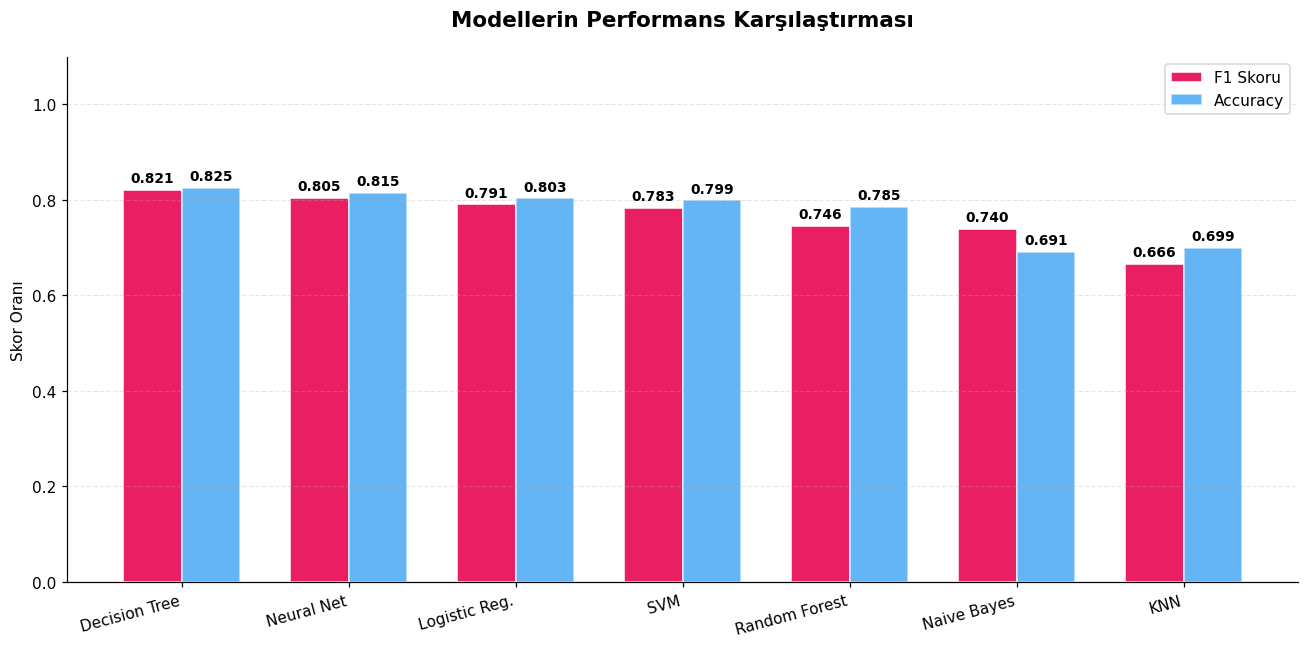

In [31]:
# F1 Skoruna göre azalan sırada sıralama
sorted_models = sorted(MN, key=lambda n: results[n]['F1'], reverse=True)

f1_sorted = [results[n]['F1'] for n in sorted_models]
acc_sorted = [results[n]['Accuracy'] for n in sorted_models]

x = np.arange(len(sorted_models))  # Etiket yerleri
width = 0.35  # Sütun genişliği

fig, ax = plt.subplots(figsize=(12, 6))

rects1 = ax.bar(x - width/2, f1_sorted, width, label='F1 Skoru', color='#E91E63', edgecolor='white')
rects2 = ax.bar(x + width/2, acc_sorted, width, label='Accuracy', color='#2196F3', edgecolor='white', alpha=0.7)

ax.set_ylabel('Skor Oranı', fontsize=10)
ax.set_title('Modellerin Performans Karşılaştırması', 
             fontsize=14, fontweight='bold', pad=20)
ax.set_xticks(x)
ax.set_xticklabels(sorted_models, rotation=15, ha='right')
ax.set_ylim(0, 1.1)
ax.legend(loc='upper right')

def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.3f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=9, fontweight='bold')

autolabel(rects1)
autolabel(rects2)

plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()